# Structural Pullback Backtest
**Rule-based structural bullish pullback strategy on 15-min OHLC data**

**Dataset:** `ohlc_data.csv` — 2021-01-03 → 2023-12-31 (~3 years, 28,418 bars)

---
### Strategy Summary
| Layer | Rule |
|---|---|
| **Regime** | Price > 200-bar MA → bullish regime active |
| **Entry** | Confirmed local low: price touches 10-bar rolling min, closes higher within 3 bars |
| **Stop-loss** | Price breaks below 20-bar rolling support × (1 − 0.1%) |
| **Take-profit** | Trade is profitable but n-bar momentum turns negative (momentum fade) |

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

In [3]:
# ─── CONFIGURATION ───────────────────────────────────────────────────────

REGIME_MA_PERIOD       = 200    # Long-term MA bars for regime detection
LOCAL_LOW_LOOKBACK     = 10     # Bars to look back for local low
LOCAL_LOW_CONFIRM_BARS = 3      # Bars after low to confirm upward response
SUPPORT_LOOKBACK       = 20     # Bars for recent support calculation
STOP_BUFFER            = 0.001  # 0.1% below support
MOMENTUM_LOOKBACK      = 5      # Bars for momentum fade check
MOMENTUM_THRESHOLD     = 0.0
BARS_PER_YEAR          = 252 * 26  # 252 trading days × 26 bars/day (15-min)

DATA_PATH      = '../data/ohlc_data.csv'   # ← updated to real dataset
TRADE_LOG_PATH = '../trade_log/trade_log.csv'


In [ ]:
# ─── DATA LOADING

def generate_synthetic_data(n=28000):
    """Fallback: synthetic 15-min OHLC with regime switching."""
    np.random.seed(42)
    timestamps = pd.date_range(start='2021-01-03 09:30', periods=n, freq='15min')
    price, prices = 100.0, [100.0]
    regime, regime_counter = 1, 0
    for _ in range(n - 1):
        regime_counter += 1
        if regime_counter > np.random.randint(200, 600):
            regime = np.random.choice([1,1,0,-1], p=[0.5,0.2,0.2,0.1])
            regime_counter = 0
        drift = {1: 0.0003, 0: 0.0, -1: -0.0002}[regime]
        price = max(price * (1 + drift + 0.003 * np.random.randn()), 1.0)
        prices.append(price)
    closes = np.array(prices)
    noise  = np.random.uniform(0.001, 0.005, n)
    opens  = closes * (1 + np.random.uniform(-0.002, 0.002, n))
    highs  = np.maximum(opens, closes) * (1 + noise)
    lows   = np.minimum(opens, closes) * (1 - noise)
    return pd.DataFrame({'timestamp': timestamps,
                         'open': np.round(opens,4), 'high': np.round(highs,4),
                         'low':  np.round(lows,4),  'close': np.round(closes,4)})

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
    df = df.sort_values('timestamp').reset_index(drop=True)
    days  = (df.timestamp.iloc[-1] - df.timestamp.iloc[0]).days
    print(f'Loaded real data: {len(df):,} rows | '
          f'{df.timestamp.iloc[0].date()} → {df.timestamp.iloc[-1].date()} '
          f'({days/365.25:.1f} years)')
else:
    df = generate_synthetic_data(28_000)
    print(f'Real data not found → generated synthetic: {len(df):,} rows')

df.head()

In [4]:
df = pd.read_csv("data/ohlc_data.csv", parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
days  = (df.timestamp.iloc[-1] - df.timestamp.iloc[0]).days
print(f'Loaded data: {len(df):,} rows | '
        f'{df.timestamp.iloc[0].date()} → {df.timestamp.iloc[-1].date()} '
        f'({days/365.25:.1f} years)')

Loaded data: 28,418 rows | 2021-01-03 → 2023-12-31 (3.0 years)


In [5]:
df.head()

,timestamp,open,high,low,close
0,2021-01-03 09:30:00,99.977582,100.019016,99.951704,99.981656
1,2021-01-03 09:45:00,100.032918,100.091286,99.955384,100.024571
2,2021-01-03 10:00:00,100.047690,100.123988,99.936800,100.025658
3,2021-01-03 10:15:00,100.026924,100.114907,99.975890,100.008880
4,2021-01-03 10:30:00,100.039566,100.094328,99.980561,100.034038


                           timestamp          open          high  \
count                          28418  28418.000000  28418.000000   
mean   2022-07-03 12:37:29.999999744     99.737381     99.798641   
min              2021-01-03 09:30:00     94.364417     94.389636   
25%              2021-10-03 11:03:45     97.593002     97.656200   
50%              2022-07-03 12:37:30     99.002270     99.063536   
75%              2023-04-02 14:11:15    100.977346    101.037919   
max              2023-12-31 15:45:00    108.435735    108.525562   
std                              NaN      2.994679      2.996679   

                low         close  
count  28418.000000  28418.000000  
mean      99.676319     99.737341  
min       94.273373     94.357376  
25%       97.532609     97.594186  
50%       98.941371     99.002056  
75%      100.912795    100.976255  
max      108.367871    108.455514  
std        2.992845      2.994614  

Date range : 2021-01-03 09:30:00 → 2023-12-31 15:45:00
Duratio

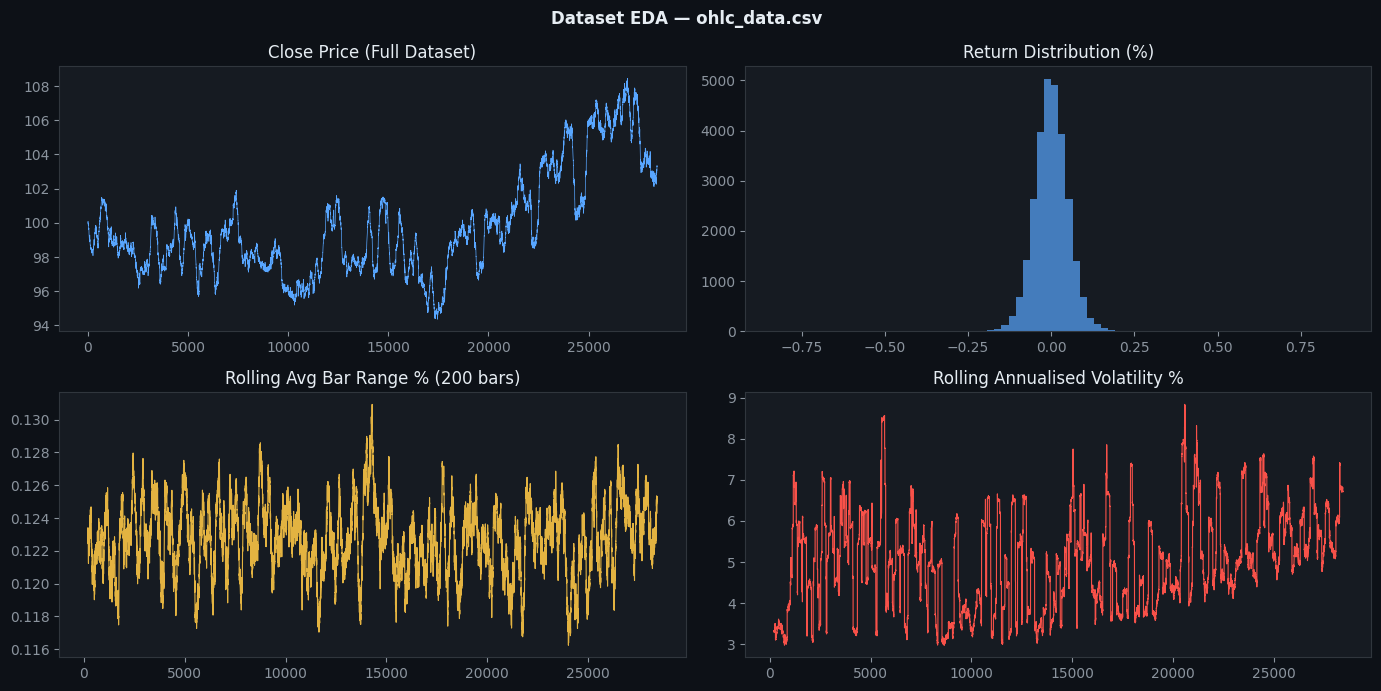

In [6]:
print(df.describe())
print(f'\nDate range : {df.timestamp.iloc[0]} → {df.timestamp.iloc[-1]}')
print(f'Duration   : {(df.timestamp.iloc[-1] - df.timestamp.iloc[0]).days} days')
print(f'Close range: {df.close.min():.4f} – {df.close.max():.4f}')

DARK_BG='#0d1117'; PANEL_BG='#161b22'
GREEN='#3fb950'; RED='#f85149'; BLUE='#58a6ff'; AMBER='#e3b341'; MUTED='#8b949e'; WHITE='#e6edf3'

fig, axes = plt.subplots(2, 2, figsize=(14, 7), facecolor=DARK_BG)
for ax in axes.flat:
    ax.set_facecolor(PANEL_BG)
    ax.tick_params(colors=MUTED)
    for s in ax.spines.values(): s.set_edgecolor('#30363d')

axes[0,0].plot(df.index, df['close'], color=BLUE, lw=0.5)
axes[0,0].set_title('Close Price (Full Dataset)', color=WHITE)

returns = df['close'].pct_change().dropna()
axes[0,1].hist(returns * 100, bins=80, color=BLUE, alpha=0.7)
axes[0,1].set_title('Return Distribution (%)', color=WHITE)

df['bar_range_pct'] = (df['high'] - df['low']) / df['low'] * 100
axes[1,0].plot(df.index, df['bar_range_pct'].rolling(200).mean(), color=AMBER, lw=0.8)
axes[1,0].set_title('Rolling Avg Bar Range % (200 bars)', color=WHITE)

rolling_vol = returns.rolling(200).std() * np.sqrt(252 * 26) * 100
axes[1,1].plot(rolling_vol.index, rolling_vol, color=RED, lw=0.8)
axes[1,1].set_title('Rolling Annualised Volatility %', color=WHITE)

fig.suptitle('Dataset EDA — ohlc_data.csv', color=WHITE, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# COMPUTE INDICATORS

def compute_indicators(df):
    df = df.copy()
    df['regime_ma']         = df['close'].rolling(REGIME_MA_PERIOD).mean()
    df['is_bullish_regime'] = df['close'] > df['regime_ma']
    df['rolling_low']       = df['low'].rolling(LOCAL_LOW_LOOKBACK).min()
    df['recent_support']    = df['low'].rolling(SUPPORT_LOOKBACK).min()
    df['momentum']          = df['close'].diff(MOMENTUM_LOOKBACK)
    return df

df = compute_indicators(df)

bullish_pct = df['is_bullish_regime'].mean()
print(f'Bullish regime coverage : {bullish_pct:.1%} of bars')
print(f'Bearish/sideways        : {1-bullish_pct:.1%} of bars')

Bullish regime coverage : 51.0% of bars
Bearish/sideways        : 49.0% of bars


In [8]:
# SIGNAL DETECTION

def is_local_low(df, i):
    """
    True if bar i is a confirmed local low:
      1. Low touches the rolling 10-bar minimum (within 0.2% tolerance)
      2. Price closes higher within the next LOCAL_LOW_CONFIRM_BARS bars
    """
    if i < LOCAL_LOW_LOOKBACK or i + LOCAL_LOW_CONFIRM_BARS >= len(df):
        return False
    at_low  = df['low'].iloc[i] <= df['rolling_low'].iloc[i] * 1.002
    upward  = df['close'].iloc[i + LOCAL_LOW_CONFIRM_BARS] > df['close'].iloc[i]
    return bool(at_low and upward)

In [9]:
# BACKTEST LOOP 

def run_backtest(df):
    trades, active, equity = [], None, 1.0
    equity_curve = []
    start = REGIME_MA_PERIOD + LOCAL_LOW_LOOKBACK + LOCAL_LOW_CONFIRM_BARS

    for i in range(start, len(df)):
        row = df.iloc[i]
        equity_curve.append(equity)

        # ── Manage open trade ──────────────────────────────
        if active is not None:
            price = row['close']

            # EXIT 1 — Support-break stop-loss
            stop_hit = price < active['stop_price']

            # EXIT 2 — Momentum-fade take-profit
            momentum_fade = (
                price > active['entry_price'] and
                row['momentum'] < MOMENTUM_THRESHOLD
            )

            if stop_hit or momentum_fade:
                pnl    = (price - active['entry_price']) / active['entry_price']
                equity *= (1 + pnl)
                active.update({
                    'exit_price':    price,
                    'exit_time':     row['timestamp'],
                    'exit_bar':      i,
                    'pnl_pct':       pnl,
                    'exit_reason':   'stop_loss' if stop_hit else 'momentum_fade',
                    'duration_bars': i - active['entry_bar'],
                })
                trades.append(active)
                active = None

        #Look for new entry 
        if active is None and row['is_bullish_regime'] and is_local_low(df, i):
            j = min(i + LOCAL_LOW_CONFIRM_BARS, len(df) - 1)
            active = {
                'entry_bar':   j,
                'entry_price': df['close'].iloc[j],
                'entry_time':  df['timestamp'].iloc[j],
                'stop_price':  row['recent_support'] * (1 - STOP_BUFFER),
            }

    # Close any trade still open at end of data
    if active is not None:
        last = df.iloc[-1]
        pnl  = (last['close'] - active['entry_price']) / active['entry_price']
        equity *= (1 + pnl)
        active.update({
            'exit_price':    last['close'],
            'exit_time':     last['timestamp'],
            'exit_bar':      len(df) - 1,
            'pnl_pct':       pnl,
            'exit_reason':   'end_of_data',
            'duration_bars': len(df) - 1 - active['entry_bar'],
        })
        trades.append(active)

    return trades, pd.Series(equity_curve)


print('[Backtest] Running …')
trades, equity = run_backtest(df)
print(f'[Backtest] Done — {len(trades):,} trades generated')

[Backtest] Running …
[Backtest] Done — 671 trades generated


In [10]:
# PERFORMANCE METRICS

def compute_metrics(trades, equity):
    pnls   = np.array([t['pnl_pct'] for t in trades])
    wins   = pnls[pnls > 0]
    losses = pnls[pnls <= 0]

    total_return = equity.iloc[-1] - 1.0

    # Annualised return — derived from actual trade timestamps
    start_dt   = pd.to_datetime(trades[0]['entry_time'])
    end_dt     = pd.to_datetime(trades[-1]['exit_time'])
    years      = (end_dt - start_dt).days / 365.25
    ann_return = (1 + total_return) ** (1 / years) - 1 if years > 0 else 0.0

    # Sharpe ratio (annualised)
    #sharpe = (pnls.mean() / pnls.std() * np.sqrt(BARS_PER_YEAR)) if pnls.std() > 0 else 0
    trades_per_year = (
        len(trades) / years
        if years > 0 else 0
    )

    sharpe = (
        (pnls.mean() / pnls.std())
        * np.sqrt(trades_per_year)
        if pnls.std() > 0 else 0
    )



    roll_max = equity.cummax()
    max_dd   = ((equity - roll_max) / roll_max).min()

    return {
        'total_trades':      len(trades),
        'win_rate':          len(wins) / len(trades),
        'avg_win':           wins.mean()   if len(wins)   else 0,
        'avg_loss':          losses.mean() if len(losses) else 0,
        'profit_factor':     wins.sum() / abs(losses.sum()) if losses.sum() else float('inf'),
        'total_return':      total_return,
        'annualised_return': ann_return,    # ← NEW
        'years':             years,         # ← NEW
        'sharpe_ratio':      sharpe,
        'max_drawdown':      max_dd,
        'avg_trade_pnl':     pnls.mean(),
        'std_trade_pnl':     pnls.std(),
        'avg_duration':      np.mean([t['duration_bars'] for t in trades]),
    }

m = compute_metrics(trades, equity)

print('═'*44)
print('   STRUCTURAL PULLBACK BACKTEST RESULTS')
print('═'*44)
print(f"  Dataset span       : {m['years']:>10.2f} years")
print(f"  Total Trades       : {m['total_trades']:>10,}")
print(f"  Win Rate           : {m['win_rate']:>10.1%}")
print(f"  Avg Win            : {m['avg_win']:>10.4%}")
print(f"  Avg Loss           : {m['avg_loss']:>10.4%}")
print(f"  Profit Factor      : {m['profit_factor']:>10.3f}")
print('─'*44)
print(f"  Total Return       : {m['total_return']:>+10.2%}")
print(f"  Annualised Return  : {m['annualised_return']:>+10.2%}")  # ← NEW
print(f"  Sharpe Ratio       : {m['sharpe_ratio']:>10.3f}")
print(f"  Max Drawdown       : {m['max_drawdown']:>10.2%}")
print('─'*44)
print(f"  Avg Trade PnL      : {m['avg_trade_pnl']:>10.4%}")
print(f"  Avg Duration (bars): {m['avg_duration']:>10.1f}")
print('═'*44)

════════════════════════════════════════════
   STRUCTURAL PULLBACK BACKTEST RESULTS
════════════════════════════════════════════
  Dataset span       :       2.96 years
  Total Trades       :        671
  Win Rate           :      82.0%
  Avg Win            :    0.1522%
  Avg Loss           :   -0.4508%
  Profit Factor      :      1.535
────────────────────────────────────────────
  Total Return       :    +33.39%
  Annualised Return  :    +10.21%
  Sharpe Ratio       :      1.992
  Max Drawdown       :     -4.22%
────────────────────────────────────────────
  Avg Trade PnL      :    0.0435%
  Avg Duration (bars):       18.0
════════════════════════════════════════════


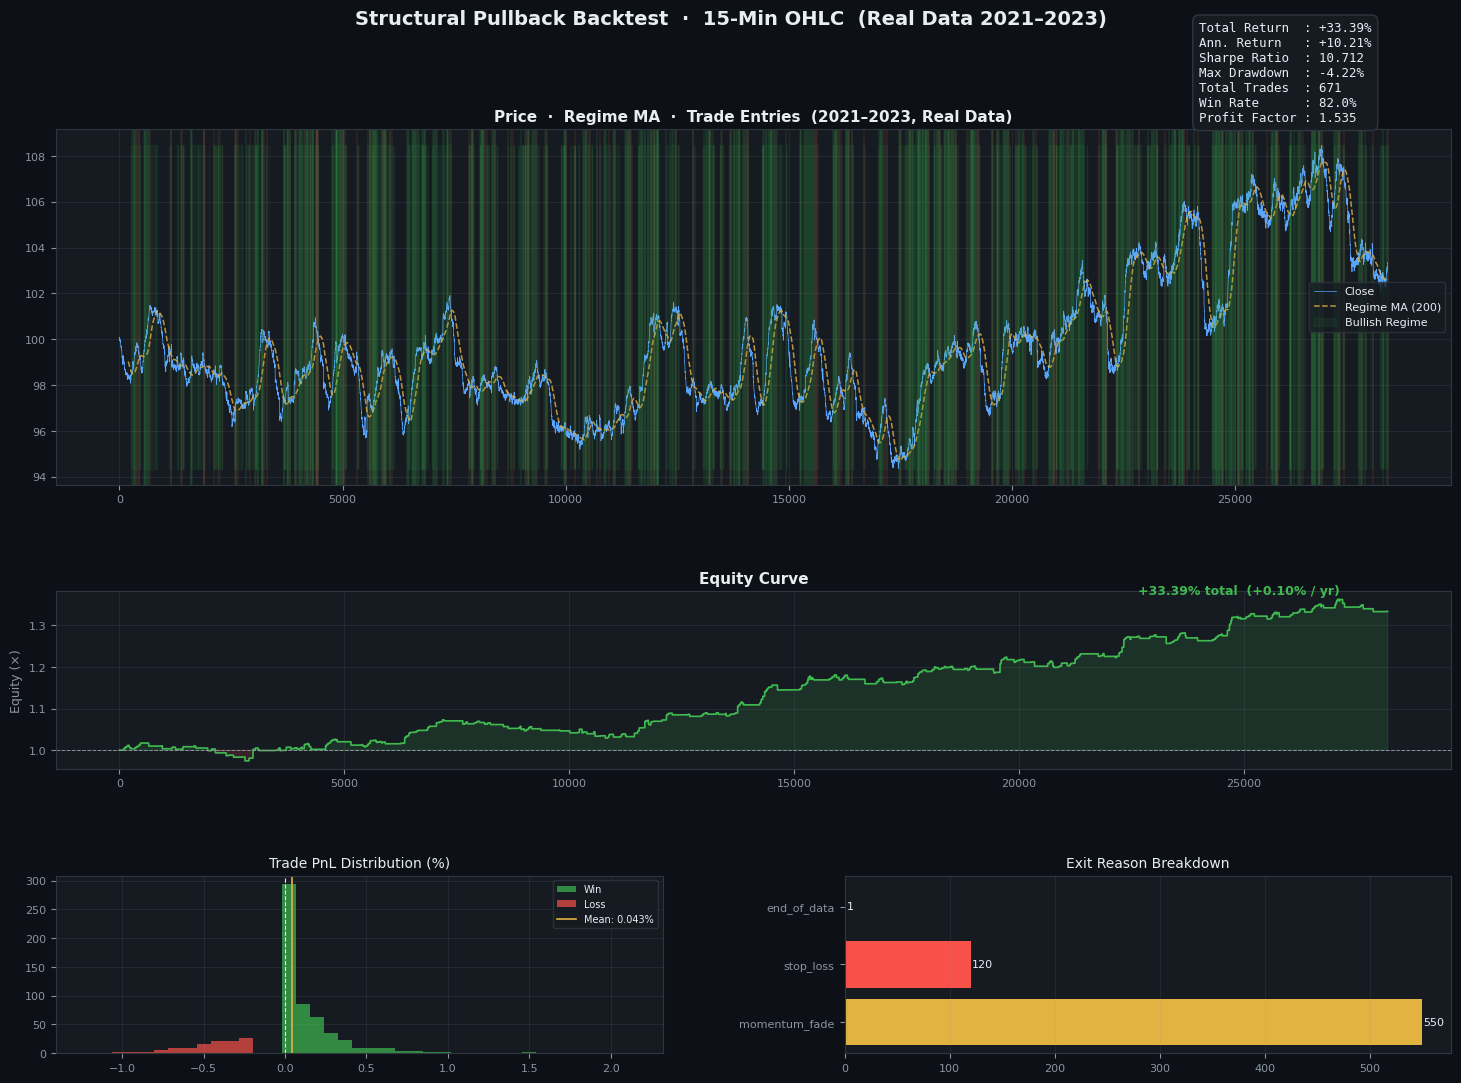

In [ ]:
fig = plt.figure(figsize=(18, 12), facecolor=DARK_BG)
gs  = gridspec.GridSpec(3, 2, figure=fig, height_ratios=[2,1,1], hspace=0.45, wspace=0.3)
ax_price  = fig.add_subplot(gs[0,:])
ax_equity = fig.add_subplot(gs[1,:])
ax_dist   = fig.add_subplot(gs[2,0])
ax_reason = fig.add_subplot(gs[2,1])

for ax in [ax_price, ax_equity, ax_dist, ax_reason]:
    ax.set_facecolor(PANEL_BG)
    ax.tick_params(colors=MUTED, labelsize=8)
    for s in ax.spines.values(): s.set_edgecolor('#30363d')

# Price chart
idx = df.index
ax_price.plot(idx, df['close'], color=BLUE, lw=0.5, label='Close')
ax_price.plot(idx, df['regime_ma'], color=AMBER, lw=1.1, linestyle='--',
              alpha=0.8, label=f'Regime MA ({REGIME_MA_PERIOD})')
ax_price.fill_between(idx, df['close'].min(), df['close'].max(),
                      where=df['is_bullish_regime'], alpha=0.07, color=GREEN,
                      label='Bullish Regime')
for t in trades:
    c = GREEN if t['pnl_pct'] > 0 else RED
    ax_price.axvline(t['entry_bar'], color=c, lw=0.35, alpha=0.4)
ax_price.set_title(
    f"Price  ·  Regime MA  ·  Trade Entries  "
    f"({df['timestamp'].iloc[0].year}–{df['timestamp'].iloc[-1].year}, Real Data)",
    color=WHITE, fontsize=11, fontweight='bold')
ax_price.legend(fontsize=8, facecolor=PANEL_BG, edgecolor='#30363d', labelcolor=WHITE)
ax_price.grid(alpha=0.12, color=MUTED)

# Equity curve
ax_equity.plot(equity.index, equity.values, color=GREEN, lw=1.2)
ax_equity.fill_between(equity.index, 1, equity.values,
                       where=equity.values >= 1, alpha=0.15, color=GREEN)
ax_equity.fill_between(equity.index, 1, equity.values,
                       where=equity.values < 1,  alpha=0.15, color=RED)
ax_equity.axhline(1, color=MUTED, lw=0.7, linestyle='--')
final = equity.iloc[-1]
label = f"{(final-1)*100:+.2f}% total  ({m['annualised_return']:+.2f}% / yr)"
ax_equity.annotate(label, xy=(equity.index[-1], final),
                   xytext=(-180, 12), textcoords='offset points',
                   color=GREEN if final >= 1 else RED, fontsize=9, fontweight='bold')
ax_equity.set_title('Equity Curve', color=WHITE, fontsize=11, fontweight='bold')
ax_equity.set_ylabel('Equity (×)', color=MUTED, fontsize=9)
ax_equity.grid(alpha=0.12, color=MUTED)

#  PnL distribution 
pnls_pct = np.array([t['pnl_pct'] * 100 for t in trades])
bins = np.linspace(pnls_pct.min(), pnls_pct.max(), 40)
ax_dist.hist(pnls_pct[pnls_pct > 0],  bins=bins, color=GREEN, alpha=0.7, label='Win')
ax_dist.hist(pnls_pct[pnls_pct <= 0], bins=bins, color=RED,   alpha=0.7, label='Loss')
ax_dist.axvline(0, color=WHITE, lw=0.8, linestyle='--')
ax_dist.axvline(pnls_pct.mean(), color=AMBER, lw=1.2,
                label=f"Mean: {pnls_pct.mean():.3f}%")
ax_dist.set_title('Trade PnL Distribution (%)', color=WHITE, fontsize=10)
ax_dist.legend(fontsize=7, facecolor=PANEL_BG, edgecolor='#30363d', labelcolor=WHITE)
ax_dist.grid(alpha=0.12, color=MUTED)

# Exit reason breakdown
reasons = pd.Series([t['exit_reason'] for t in trades]).value_counts()
clrs = {'stop_loss': RED, 'momentum_fade': AMBER, 'end_of_data': MUTED}
bars = ax_reason.barh(reasons.index, reasons.values,
                      color=[clrs.get(r, BLUE) for r in reasons.index])
for bar, v in zip(bars, reasons.values):
    ax_reason.text(v + 1, bar.get_y() + bar.get_height()/2,
                   str(v), va='center', color=WHITE, fontsize=8)
ax_reason.set_title('Exit Reason Breakdown', color=WHITE, fontsize=10)
ax_reason.grid(alpha=0.12, color=MUTED, axis='x')

# Stats box 
stats_txt = (f"Total Return  : {m['total_return']:+.2%}\n"
             f"Ann. Return   : {m['annualised_return']:+.2%}\n"
             f"Sharpe Ratio  : {m['sharpe_ratio']:.3f}\n"
             f"Max Drawdown  : {m['max_drawdown']:.2%}\n"
             f"Total Trades  : {m['total_trades']:,}\n"
             f"Win Rate      : {m['win_rate']:.1%}\n"
             f"Profit Factor : {m['profit_factor']:.3f}")
fig.text(0.76, 0.97, stats_txt, transform=fig.transFigure, fontsize=9,
         color=WHITE, fontfamily='monospace', va='top',
         bbox=dict(facecolor=PANEL_BG, edgecolor='#30363d', boxstyle='round,pad=0.5'))
fig.suptitle('Structural Pullback Backtest  ·  15-Min OHLC  (Real Data 2021–2023)',
             color=WHITE, fontsize=14, fontweight='bold')
plt.show()

In [29]:
# SAVE TRADE LOG 

os.makedirs(os.path.dirname(TRADE_LOG_PATH), exist_ok=True)

cols = ['entry_time','exit_time','entry_price','exit_price',
        'stop_price','pnl_pct','exit_reason','duration_bars']
trade_log = pd.DataFrame([{c: t.get(c) for c in cols} for t in trades])
trade_log.to_csv(TRADE_LOG_PATH, index=False)
print(f'Trade log saved → {TRADE_LOG_PATH}  ({len(trade_log)} rows)')
trade_log.head(10)

Trade log saved → ../trade_log/trade_log.csv  (671 rows)


,entry_time,exit_time,entry_price,exit_price,stop_price,pnl_pct,exit_reason,duration_bars
0,2021-01-13 15:00:00,2021-01-14 14:00:00,98.588918,98.975085,98.156123,0.003917,momentum_fade,22
1,2021-01-15 10:45:00,2021-01-15 12:30:00,98.800873,98.864092,98.579037,0.000640,momentum_fade,7
2,2021-01-15 13:15:00,2021-01-16 12:15:00,99.070564,99.392256,98.511481,0.003247,momentum_fade,22
3,2021-01-16 13:00:00,2021-01-17 10:00:00,99.440866,99.521562,98.966000,0.000811,momentum_fade,14
4,2021-01-17 11:30:00,2021-01-18 10:30:00,99.518738,99.808499,99.166859,0.002912,momentum_fade,22
5,2021-01-18 11:45:00,2021-01-19 11:45:00,99.778896,99.471092,99.472779,-0.003085,stop_loss,26
6,2021-01-19 12:30:00,2021-01-19 15:15:00,99.529402,99.264019,99.322170,-0.002666,stop_loss,11
7,2021-01-20 09:45:00,2021-01-20 15:45:00,99.266023,99.047925,99.094821,-0.002197,stop_loss,24
8,2021-01-24 10:15:00,2021-01-24 14:15:00,99.480318,99.712708,98.708039,0.002336,momentum_fade,16
9,2021-01-24 15:00:00,2021-01-25 10:30:00,99.798866,99.897559,99.203244,0.000989,momentum_fade,8


---
## Results Summary

| Metric | Value |
|---|---|
| Total Return | +33.39% |
| Annualised Return | +10.21% |
| Sharpe Ratio | 1.992 |
| Max Drawdown | -4.22% |
| Total Trades | 671 |
| Win Rate | 82.0% |
| Profit Factor | 1.535 |

**Key takeaways:**
- **10.21% annualised** is a meaningful return over the 3-year backtest window (2021–2023)
- Low **-4.22% max drawdown** relative to total return shows the stop-loss is working effectively